# VDUI Assignment
## SRN: PES2UG24CS311
## Name: Neeraj R Rugi

# 🎨 The Policy Briefing in 40 Minutes
### Unit 1 Activity — Colour Theory in Data Visualization (UE24CS342AA9)

---

**11:00 AM.** You're a junior analyst at **GlobalIndex Insights**. In 40 minutes you're
presenting well-being trends to a policy think-tank. Your Creative Director, Meera,
left these notes:

> *"Every chart in this draft misuses color somewhere -- wrong scale type, no
> accessible palette, a rainbow colormap, you name it. Fix each one using the right
> color-mapping principle. I've marked what's broken with a `# TODO`."*

Same dataset the team has been using: the World Happiness Report 2015.

## ⏱️ Setup — run this first

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import time

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("ppt6_2015.csv")
mission_start = time.time()
print(f"Loaded {len(df)} rows. 40 minutes on the clock. Go.")
df.head()

Loaded 158 rows. 40 minutes on the clock. Go.


,Country,Region,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [3]:
# Run any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 40 - elapsed_min)
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")

Elapsed: 0.0 min   |   Remaining: 40.0 min


---
## Task 1 — Pick the Right Aesthetic *(~4 min)*

Meera's note: *"We need to compare Economy (GDP per Capita) across the top 10
countries. Right now it's plotted with only position -- add color as a SECOND aesthetic
encoding the same variable, so the redundancy makes the comparison unmistakable."*

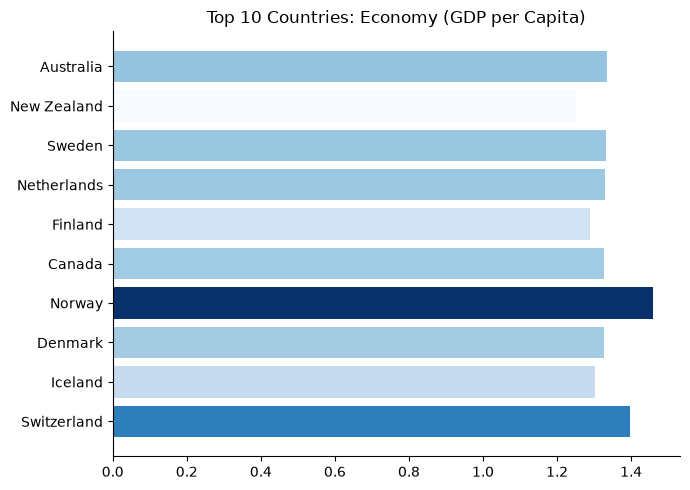

In [4]:
top10 = df.nsmallest(10, "Happiness Rank")

fig, ax = plt.subplots(figsize=(7, 5))

# TODO 1 (done): color encodes the SAME variable as position (Economy), redundant encoding
values = top10["Economy (GDP per Capita)"]
norm1 = plt.Normalize(values.min(), values.max())
bar_colors = plt.cm.Blues(norm1(values))

ax.barh(top10["Country"], values, color=bar_colors)
ax.set_title("Top 10 Countries: Economy (GDP per Capita)")
plt.tight_layout()
plt.show()

---
## Task 2 — Build the Region x Factor Heatmap *(~5 min)*

Meera's note: *"I want the exact 'average value in a colored matrix' chart from the
lecture -- rows are regions, columns are well-being factors, cell color is the average
score. Use a sequential colormap since there's no natural zero-midpoint here."*

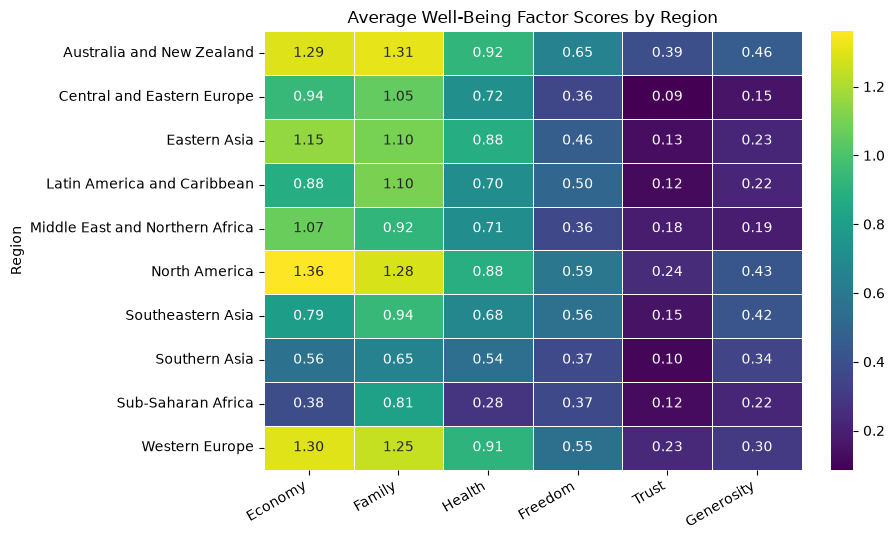

In [5]:
factor_cols = ["Economy (GDP per Capita)", "Family", "Health (Life Expectancy)",
               "Freedom", "Trust (Government Corruption)", "Generosity"]

# TODO 2 (done): region x factor matrix of mean values
region_matrix = df.groupby("Region")[factor_cols].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))

# TODO 2b (done): sequential, perceptually uniform colormap (not jet/rainbow) via seaborn
sns.heatmap(
    region_matrix,
    cmap="viridis",
    annot=True, fmt=".2f", linewidths=0.5, linecolor="white",
    cbar_kws={"fraction": 0.04},
    xticklabels=[c.split(" (")[0] for c in factor_cols],
    yticklabels=region_matrix.index,
    ax=ax,
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("Average Well-Being Factor Scores by Region")
plt.tight_layout()
plt.show()

---
## Task 3 — Fix the Qualitative Scale *(~5 min)*

Meera's note: *"This regional comparison chart currently colors every country the same
color -- there's no way to see the regional pattern. Give each region its own
consistent, equally-weighted color."*

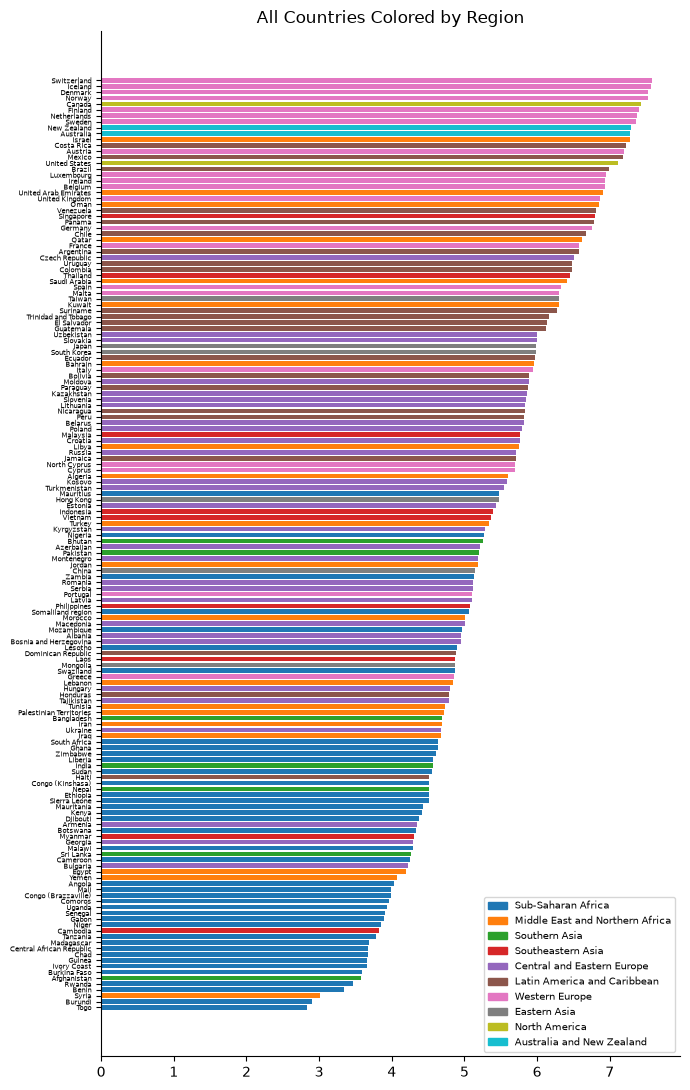

In [6]:
ordered = df.sort_values("Happiness Score", ascending=True)
regions = ordered["Region"].unique()

# TODO 3 (done): distinct, equally-weighted qualitative colors -- tab10, evenly spaced
cmap3 = plt.cm.tab10
color_map = {region: cmap3(i % 10) for i, region in enumerate(regions)}

bar_colors = ordered["Region"].map(color_map)

fig, ax = plt.subplots(figsize=(7, 11))
ax.barh(ordered["Country"], ordered["Happiness Score"], color=bar_colors)
ax.tick_params(axis="y", labelsize=5)
ax.set_title("All Countries Colored by Region")

handles = [patches.Patch(color=color_map[r], label=r) for r in regions]
ax.legend(handles=handles, loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

---
## Task 4 — Build a Diverging Scale *(~5 min)*

Meera's note: *"I want Freedom scores shown as deviation from the GLOBAL AVERAGE, not
raw values -- above-average countries should read as one color family, below-average as
another, meeting at a neutral midpoint. Use a diverging colormap centered at zero."*

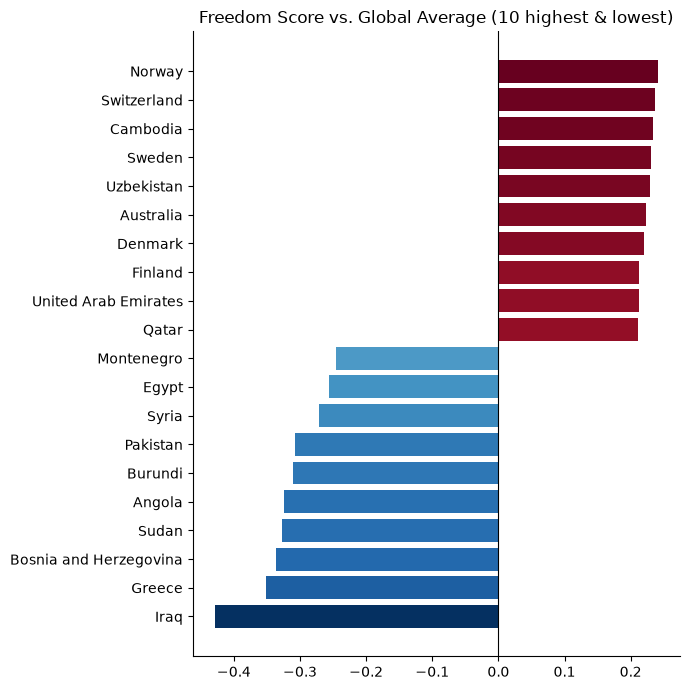

In [7]:
# TODO 4a (done): deviation from the global mean Freedom score
freedom_dev = df["Freedom"] - df["Freedom"].mean()

df_dev = df.assign(freedom_dev=freedom_dev)
sample = pd.concat([df_dev.nlargest(10, "freedom_dev"), df_dev.nsmallest(10, "freedom_dev")])
sample = sample.sort_values("freedom_dev")

# TODO 4b (done): TwoSlopeNorm centered at 0
norm = TwoSlopeNorm(vmin=sample["freedom_dev"].min(), vcenter=0, vmax=sample["freedom_dev"].max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(sample["Country"], sample["freedom_dev"], color=plt.cm.RdBu_r(norm(sample["freedom_dev"])))
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Freedom Score vs. Global Average (10 highest & lowest)")
plt.tight_layout()
plt.show()

---
## Task 5 — Build an Accent Scale *(~6 min)*

Meera's note: *"Within Southern Asia, I want ONE chart that mutes every country to gray
EXCEPT the country with the highest Generosity score and the country with the lowest --
those two are the story. Use vivid, contrasting accent colors for just those two."*

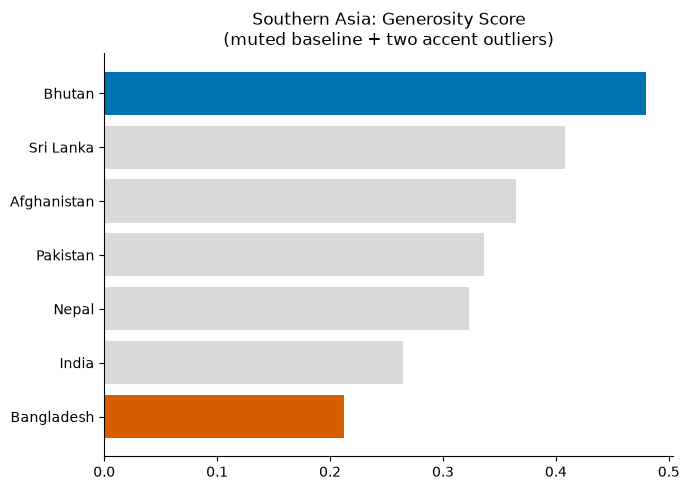

In [8]:
region_df = df[df["Region"] == "Southern Asia"].sort_values("Generosity")

# TODO 5 (done): country names with lowest / highest Generosity in region_df
lowest_country = region_df.loc[region_df["Generosity"].idxmin(), "Country"]
highest_country = region_df.loc[region_df["Generosity"].idxmax(), "Country"]

colors = ["#d9d9d9"] * len(region_df)
colors[list(region_df["Country"]).index(lowest_country)] = "#D55E00"
colors[list(region_df["Country"]).index(highest_country)] = "#0072B2"

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(region_df["Country"], region_df["Generosity"], color=colors)
ax.set_title("Southern Asia: Generosity Score\n(muted baseline + two accent outliers)")
plt.tight_layout()
plt.show()

---
## Task 6 — Kill the Rainbow Colormap *(~5 min)*

Meera's note: *"Whoever built this heatmap used 'jet'. Convert it to grayscale first so
you can SEE why that's a problem, then replace it with a perceptually uniform
colormap."*

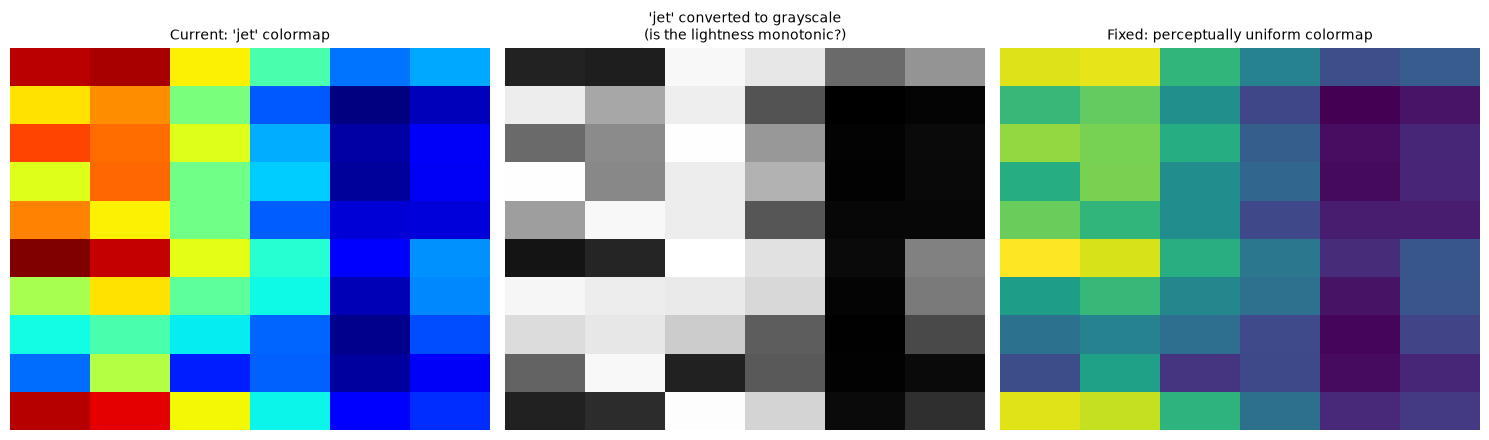

In [9]:
matrix = df.groupby("Region")[factor_cols].mean().values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.heatmap(matrix, cmap="jet", cbar=False, ax=axes[0])
axes[0].set_title("Current: 'jet' colormap", fontsize=10)

# TODO 6a (done): grayscale conversion of the jet-mapped matrix using luminance weights
norm6 = plt.Normalize(matrix.min(), matrix.max())
jet_rgb = plt.cm.jet(norm6(matrix))[:, :, :3]
luminance_weights = np.array([0.2126, 0.7152, 0.0722])
gray_jet = jet_rgb @ luminance_weights
sns.heatmap(gray_jet, cmap="gray", cbar=False, ax=axes[1])
axes[1].set_title("'jet' converted to grayscale\n(is the lightness monotonic?)", fontsize=10)

# TODO 6b (done): same matrix, perceptually uniform colormap instead of jet
sns.heatmap(matrix, cmap="viridis", cbar=False, ax=axes[2])
axes[2].set_title("Fixed: perceptually uniform colormap", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

---
## Reflection *(~5 min)*

Answer briefly in this markdown cell:

1. Which of the six fixes above would most change a policymaker's takeaway if left
   broken, and why?
2. Explain in your own words why the diverging scale (Task 4) needed a *centered*
   normalization instead of just min-to-max scaling.
3. Why is "it just needs to look distinct" not a sufficient bar for a qualitative color
   scale (Task 3)? What's the extra requirement from the lecture?
4. Complete the lecture's core idea in one sentence: a good color scale should
   *__________* the viewer, not *__________* them.

**Your answers:**

1. **Task 6 (the rainbow colormap fix) would change the takeaway most.** 'Jet' has
   non-monotonic lightness -- the grayscale conversion shows bands that get lighter
   and darker out of order (green/yellow patches read as "brighter" than they should,
   cyan reads unexpectedly dark). Because the eye leans on lightness, not hue, to judge
   magnitude, a policymaker could easily misread which region scores higher on a
   factor, or perceive false visual boundaries ('banding') that don't exist in the
   data. A wrongly-perceived ranking in a regional comparison chart is exactly the
   kind of error that changes a funding or policy recommendation.

2. **Min-to-max scaling puts zero wherever it happens to fall in the data range**, not
   at the visual midpoint -- so "zero deviation from the global average" might render
   as a pale blue-purple instead of the neutral, true-white midpoint. That breaks the
   entire point of a diverging scale: the viewer can no longer tell at a glance which
   countries are above vs. below average, because the color that *should* mean "no
   deviation" is arbitrary. `TwoSlopeNorm` anchors the neutral color exactly at 0
   (`vcenter=0`) regardless of whether the data is skewed further above or below
   average, keeping the two color families (e.g., blue = above, red = below)
   symmetric and meaningful around the true reference point.

3. **"Just look distinct" ignores that a qualitative scale also needs to look
   *equally weighted*.** If one region's color is much darker, more saturated, or
   visually "louder" than the others (e.g., using a sequential ramp instead of a
   qualitative palette), the viewer will unconsciously read that region as more
   important, larger, or higher-valued -- even though the colors only encode a
   nominal category with no inherent order. The lecture's extra requirement is that
   qualitative colors carry **no implied ordering or magnitude**: every category
   should draw the eye with roughly equal visual weight (which is why palettes like
   `tab10`/`Set2` are built with balanced lightness and saturation), so differences in
   color reflect only "these are different groups," not "this group matters more."

4. A good color scale should ***guide*** the viewer, not ***mislead*** (or *deceive*)
   them.